# Linear Regression Analysis (R)

This notebook analyzes the relationship between years of experience and salary using a simple linear regression model. It reports the fitted equation, model fit, a prediction at 6 years of experience, and a polished regression graph.

## Step 1: Load the Data

We read the CSV file into an R data frame. Each row represents an observation with predictor and response variables.

In [1]:
x_column <- "YearsExperience"
y_column <- "Salary"
predict_years <- 6
output_file <- "linear_regression_r_output.png"

format_currency <- function(value) {
  paste0("$", format(round(value), big.mark = ",", scientific = FALSE, trim = TRUE))
}

data <- read.csv("regression_data.csv")
head(data)

,YearsExperience,Salary
,<dbl>,<dbl>
1,1.1,39343
2,1.3,46205
3,1.5,37731
4,2.0,43525
5,2.2,39891
6,2.9,56642


## Step 2: Fit a Simple Linear Regression Model

We fit the model `Salary = beta_0 + beta_1 * YearsExperience` using ordinary least squares with `lm()`.

In [2]:
formula <- as.formula(paste(y_column, "~", x_column))
model <- lm(formula, data = data)

coefs <- coef(model)
intercept <- unname(coefs[1])
slope <- unname(coefs[2])
equation <- sprintf("Salary = %.4f + %.4f * YearsExperience", intercept, slope)

cat(sprintf("Slope: %.4f\n", slope))
cat(sprintf("Intercept: %.4f\n", intercept))
cat(sprintf("Regression equation: %s\n", equation))

Slope: 8285.2921
Intercept: 29203.5227
Regression equation: Salary = 29203.5227 + 8285.2921 * YearsExperience


## Step 3: Evaluate the Model and Predict Salary

We calculate R-squared and predict the salary for 6 years of experience.

In [3]:
r2 <- summary(model)$r.squared
predicted_salary <- as.numeric(
  predict(model, newdata = data.frame(YearsExperience = predict_years))
)

cat(sprintf("R-squared: %.4f\n", r2))
cat(sprintf(
  "Predicted salary at %g years of experience: %.2f\n",
  predict_years,
  predicted_salary
))

R-squared: 0.7852
Predicted salary at 6 years of experience: 78915.28


## Step 4: Create the Regression Graph

The final graph shows observed data, the fitted line, the regression equation, R-squared, and the highlighted prediction at 6 years of experience.

pdf 
  2

Saved regression plot to linear_regression_r_output.png


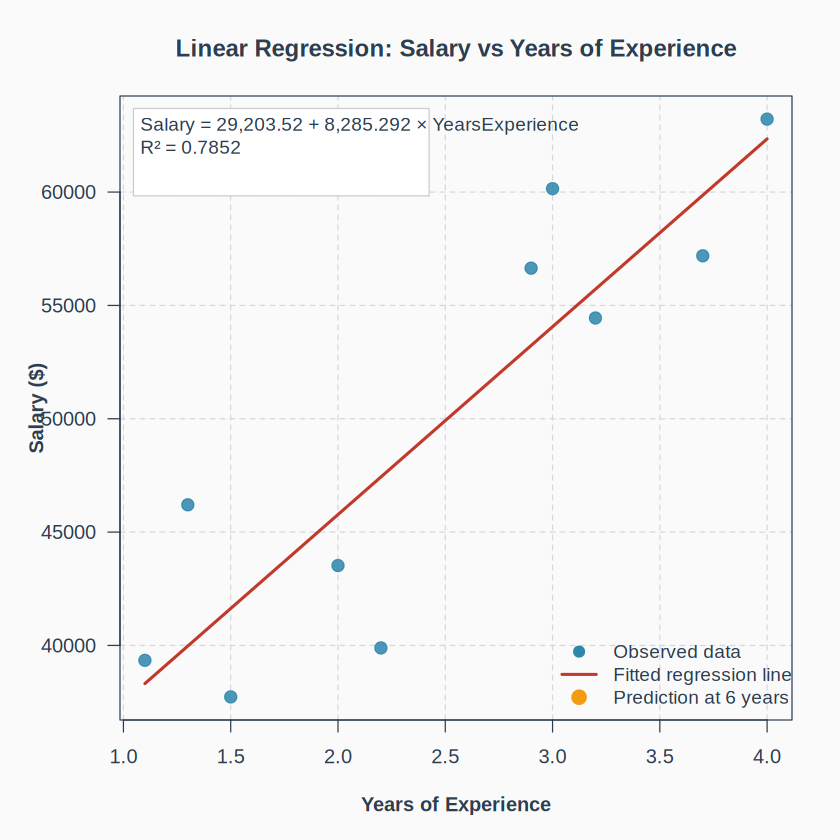

In [4]:
x_vals <- data[[x_column]]
y_vals <- data[[y_column]]
x_line <- seq(min(x_vals), max(x_vals), length.out = 100)
y_line <- intercept + slope * x_line

stats_label <- paste0(
  sprintf(
    "Salary = %s + %s × YearsExperience",
    format(intercept, big.mark = ",", nsmall = 2),
    format(slope, big.mark = ",", nsmall = 2)
  ),
  sprintf("\nR² = %.4f", r2)
)

draw_regression_plot <- function() {
  par(
    mar = c(5, 5, 4, 2),
    bg = "#FAFAFA",
    fg = "#2C3E50",
    col.axis = "#2C3E50",
    col.lab = "#2C3E50",
    col.main = "#2C3E50",
    font.lab = 2,
    font.main = 2,
    las = 1
  )

  plot(
    x_vals,
    y_vals,
    pch = 19,
    cex = 1.35,
    col = adjustcolor("#2E86AB", alpha.f = 0.85),
    xlab = "Years of Experience",
    ylab = "Salary ($)",
    main = "Linear Regression: Salary vs Years of Experience",
    panel.first = grid(col = "#D5D8DC", lty = "dashed")
  )

  lines(x_line, y_line, col = "#C0392B", lwd = 2.5)
  points(
    predict_years,
    predicted_salary,
    pch = 21,
    bg = "#F39C12",
    col = "#2C3E50",
    cex = 2.2,
    lwd = 1.5
  )

  text(
    predict_years + 0.35,
    predicted_salary + 3500,
    labels = paste0("Predicted salary: ", format_currency(predicted_salary)),
    pos = 4,
    font = 2,
    cex = 0.95,
    col = "#2C3E50"
  )

  legend(
    "bottomright",
    legend = c(
      "Observed data",
      "Fitted regression line",
      sprintf("Prediction at %g years", predict_years)
    ),
    col = c("#2E86AB", "#C0392B", "#F39C12"),
    pch = c(19, NA, 21),
    lty = c(NA, 1, NA),
    lwd = c(NA, 2.5, NA),
    pt.bg = c(NA, NA, "#F39C12"),
    pt.cex = c(1.2, NA, 1.6),
    bty = "n",
    cex = 0.95
  )

  rect(
    grconvertX(0.02, "npc"),
    grconvertY(0.98, "npc"),
    grconvertX(0.46, "npc"),
    grconvertY(0.84, "npc"),
    col = adjustcolor("white", alpha.f = 0.95),
    border = "#CCCCCC"
  )
  text(
    grconvertX(0.03, "npc"),
    grconvertY(0.965, "npc"),
    labels = stats_label,
    adj = c(0, 1),
    cex = 0.95
  )
}

draw_regression_plot()

png(output_file, width = 1200, height = 600, res = 150)
draw_regression_plot()
dev.off()

cat(sprintf("Saved regression plot to %s\n", output_file))

## Summary

The fitted model estimates salary as a linear function of years of experience. The regression equation, R-squared, and the predicted salary at 6 years are reported above, and the saved graph matches the standalone R script output.

In [5]:
cat("Analysis complete.\n")
cat(sprintf("Regression equation: %s\n", equation))
cat(sprintf("R-squared: %.4f\n", r2))
cat(sprintf("Predicted salary at 6 years: %.2f\n", predicted_salary))

Analysis complete.
Regression equation: Salary = 29203.5227 + 8285.2921 * YearsExperience
R-squared: 0.7852
Predicted salary at 6 years: 78915.28
